In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

# scikit-learn imports
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from scipy import stats

In [2]:
raw_dataframe = pd.read_csv("../data/raw/Validators' Skill Sheet - Complexity Score.csv")

In [3]:
raw_dataframe.head()

,ID,Job Title,Job Description,Sum of Weights,Sum of (Complexity x Weight),Complexity Score,Amount,Currency,Country,Country Category
0,4,Build API access to data,Project Title: Build API access to acquired fl...,840,3710,4.416667,500,USD,United Kingdom,High income
1,100,Multimodal Neural Network for Financial Data A...,Project Overview: I am looking to develop a cu...,1550,6970,4.496774,500,USD,United Arab Emirates,High income
2,163,Reconciliation of GST Invoices between two Sou...,I am looking for a skilled developer who can h...,670,2570,3.835821,7000,INR,India,Lower middle income
3,194,Need complex sample tableau dashboards (financ...,Project Description: Complex Sample Tableau Da...,1030,4410,4.281553,140,USD,United States,High income
4,256,App Statistics Module Developer Needed,Project Overview: Seeking an experienced app d...,910,3970,4.362637,500,USD,Denmark,High income


## Preprocessing

In [4]:
from helper import convert_to_usd

Convert 'Amount' column that is not USD from 'Currency' to USD.

In [5]:
raw_dataframe["Amount"] = raw_dataframe.apply(lambda row: convert_to_usd(row, "Amount"), axis=1)

Filtering out relevant columns that will be used for modelling.

In [6]:
relevent_columns = [
    "ID",
    "Complexity Score",
    "Amount",
    "Country",
    "Country Category",
]

filtered_dataframe = raw_dataframe[relevent_columns].copy()

In [7]:
# Remove salary outliers using z-score threshold of 3.
amount_mean = filtered_dataframe["Amount"].mean()
amount_std = filtered_dataframe["Amount"].std(ddof=0)

if amount_std != 0:
    amount_z_scores = (filtered_dataframe["Amount"] - amount_mean) / amount_std
    filtered_dataframe = filtered_dataframe[amount_z_scores.abs() <= 3].copy()

## Data Exploration

Distribution of complexity score.

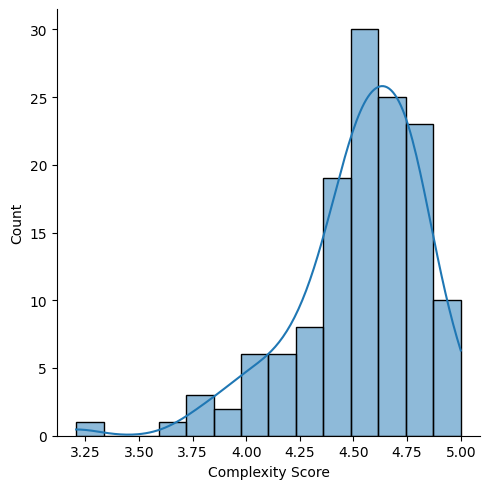

In [8]:
data = filtered_dataframe[["Complexity Score"]]
sns.displot(data=data, x="Complexity Score", kde=True)

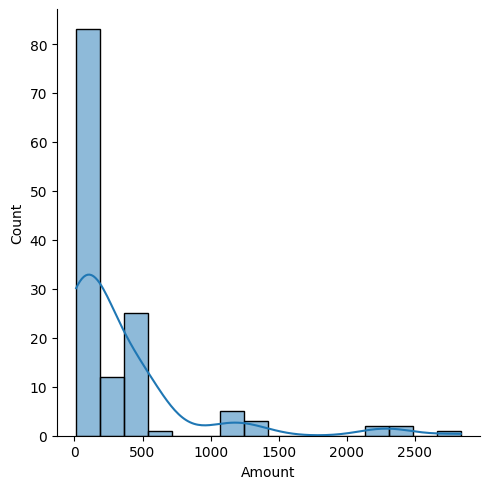

In [9]:
salaries = filtered_dataframe[["Amount"]]
sns.displot(data=salaries, x="Amount", kde=True)

<Axes: xlabel='Amount', ylabel='Complexity Score'>

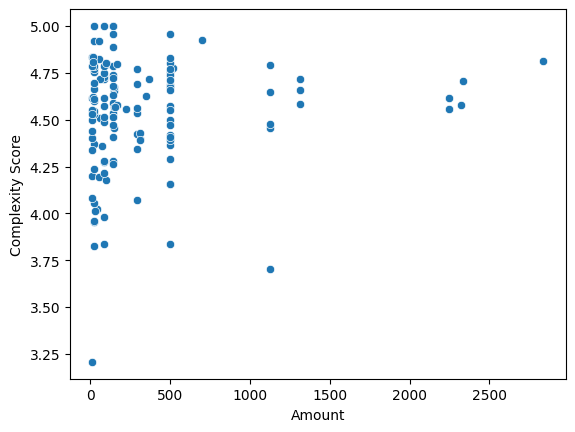

In [10]:

sns.scatterplot(data=filtered_dataframe, x="Amount", y="Complexity Score")

Complexity Score vs Amount by Country Category (1x3 Scatter Plot)

/var/folders/jd/rmzvvh4s2jzg55h334m9_q040000gn/T/ipykernel_3742/3908901556.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(


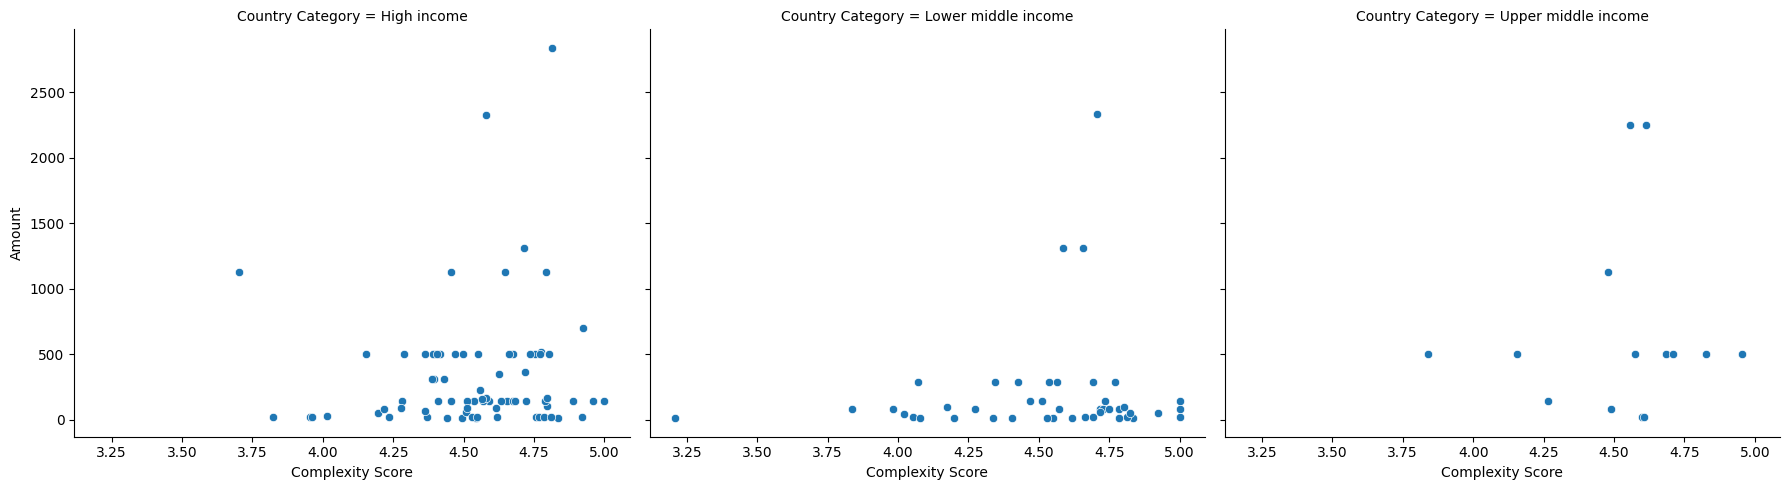

In [11]:
sns.relplot(
    data=filtered_dataframe,
    x="Complexity Score",
    y="Amount",
    col="Country Category",
    height=5,
    aspect=1.2,
    palette="Set2"
)

Average salaries from country categories

,Country Category,Amount
2,Upper middle income,670.473469
0,High income,339.150512
1,Lower middle income,202.676510


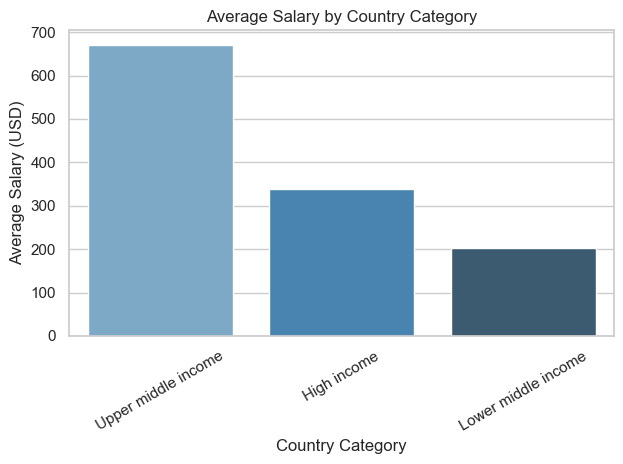

In [12]:
sns.set_theme(style="whitegrid")

avg_salaries_by_country_category = (
    filtered_dataframe.groupby("Country Category", as_index=False)["Amount"]
    .mean()
    .sort_values("Amount", ascending=False)
)

ax = sns.barplot(
    data=avg_salaries_by_country_category,
    x="Country Category",
    y="Amount",
    palette="Blues_d",
    hue="Country Category",
    dodge=False,
    legend=False,
)
ax.set_title("Average Salary by Country Category")
ax.set_xlabel("Country Category")
ax.set_ylabel("Average Salary (USD)")
ax.tick_params(axis="x", rotation=30)
ax.figure.tight_layout()

avg_salaries_by_country_category

## Modelling
we'll be performing multi-variate regression

In [13]:
# Predict complexity score directly from raw (non-normalized) features.
dataset_without_normalization = filtered_dataframe.drop(columns=["ID"]).copy()
X = dataset_without_normalization[["Complexity Score", "Country Category", "Country"]]
y = dataset_without_normalization["Amount"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), ["Country Category", "Country"]),
    ],
    remainder="passthrough",
    sparse_threshold=0,
    verbose_feature_names_out=False,
)

In [15]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [17]:
r2_raw = r2_score(y_test, y_pred)
rmse_raw = root_mean_squared_error(y_test, y_pred)
mae_raw = mean_absolute_error(y_test, y_pred)
mse_raw = mean_squared_error(y_test, y_pred)
p = X_test.shape[1]

y_pred_train = model.predict(X_train)
ss_res = np.sum((y_train - y_pred_train) ** 2)  # Residual sum of squares
ss_tot = np.sum((y_train - np.mean(y_train)) ** 2)  # Total sum of squares
mean_sq_res = ss_res / (len(y_train) - p - 1)
mean_sq_tot = ss_tot / (p - 1)
f_statistic = mean_sq_tot / mean_sq_res
p_value = 1 - stats.f.cdf(f_statistic, p - 1, len(y_train) - p - 1)

# Display all results
print("=== Extended Regression Metrics ===\n")
print("Raw-Scale Metrics (Model's prediction space):")
print(f"  R²: {r2_raw:.4f}")
print(f"  MAE: {mae_raw:.4f}")
print(f"  MSE: {mse_raw:.4f}")
print(f"  RMSE: {rmse_raw:.4f}\n")

print("Model Significance:")
print(f"  F-statistic: {f_statistic:.4f}")
print(f"  P-value: {p_value:.4e}")

=== Extended Regression Metrics ===

Raw-Scale Metrics (Model's prediction space):
  R²: -0.6933
  MAE: 302.3421
  MSE: 173920.6192
  RMSE: 417.0379

Model Significance:
  F-statistic: 90.3843
  P-value: 1.1102e-16


## Optimization

In [ ]:
import optuna
from sklearn.linear_model import ElasticNet, Lasso, Ridge
from sklearn.model_selection import KFold, cross_val_score

X_opt = dataset_without_normalization[["Complexity Score", "Country", "Country Category"]]
y_opt = dataset_without_normalization["Amount"]

X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(
    X_opt, y_opt, test_size=0.2, random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

def build_linear_regressor(params):
    model_type = params["model_type"]
    if model_type == "Ridge":
        return Ridge(alpha=params["alpha"])
    if model_type == "Lasso":
        return Lasso(alpha=params["alpha"], max_iter=20000)
    return ElasticNet(
        alpha=params["alpha"],
        l1_ratio=params["l1_ratio"],
        max_iter=20000,
    )

def objective(trial):
    model_type = trial.suggest_categorical("model_type", ["Ridge", "Lasso", "ElasticNet"])
    alpha = trial.suggest_float("alpha", 1e-4, 100.0, log=True)

    params = {
        "model_type": model_type,
        "alpha": alpha,
    }

    if model_type == "ElasticNet":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.05, 0.95)

    preprocessor_opt = ColumnTransformer(
        transformers=[
            ("categorical", OneHotEncoder(handle_unknown="ignore"), ["Country", "Country Category"]),
        ],
        remainder="passthrough",
        sparse_threshold=0,
        verbose_feature_names_out=False,
    )

    model_opt = Pipeline(
        steps=[
            ("preprocessor", preprocessor_opt),
            ("regressor", build_linear_regressor(params)),
        ]
    )

    scores = cross_val_score(
        model_opt,
        X_train_opt,
        y_train_opt,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
    )

    return -scores.mean()

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=40, show_progress_bar=False)

best_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), ["Country", "Country Category"]),
    ],
    remainder="passthrough",
    sparse_threshold=0,
    verbose_feature_names_out=False,
)

best_model = Pipeline(
    steps=[
        ("preprocessor", best_preprocessor),
        ("regressor", build_linear_regressor(study.best_params)),
    ]
)

best_model.fit(X_train_opt, y_train_opt)
y_pred_opt = best_model.predict(X_test_opt)

optimized_results = {
    "Model": study.best_params["model_type"],
    "MAE": mean_absolute_error(y_test_opt, y_pred_opt),
    "MSE": mean_squared_error(y_test_opt, y_pred_opt),
    "RMSE": root_mean_squared_error(y_test_opt, y_pred_opt),
    "R2": r2_score(y_test_opt, y_pred_opt),
    "Best CV RMSE": study.best_value,
    "Best Params": study.best_params,
}

optimized_results

/Users/nickanthonymiras/miniconda3/envs/datascience/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-27 14:58:45,561] A new study created in memory with name: no-name-d3a36046-d8c3-49a4-bbe9-a4a5d3a6152d
[I 2026-03-27 14:58:48,241] Trial 0 finished with value: 604.8716305804494 and parameters: {'model_type': 'Lasso', 'alpha': 0.39079671568228824}. Best is trial 0 with value: 604.8716305804494.
[I 2026-03-27 14:58:49,958] Trial 1 finished with value: 538.7018170956378 and parameters: {'model_type': 'Ridge', 'alpha': 15.741890047456641}. Best is trial 1 with value: 538.7018170956378.
[I 2026-03-27 14:58:51,546] Trial 2 finished with value: 538.3110149839433 and parameters: {'model_type': 'Lasso', 'alpha': 65.98711072054076}. Best is trial 2 with value: 538.3110149839433.
[I 2026-03-27 14:58:53,1

{'Model': 'ElasticNet',
 'MAE': 288.93478324124493,
 'MSE': 122799.50584358953,
 'RMSE': 350.42760428309515,
 'R2': -0.19558249034054342,
 'Best CV RMSE': 537.9227663891598,
 'Best Params': {'model_type': 'ElasticNet',
  'alpha': 0.8538212797333324,
  'l1_ratio': 0.40133763380676674}}

# Conclusion